**Autor:** [Twoje Imię i Nazwisko]
**Grupa:** Sieci CNN (indeks kończący się na 5-9)

Celem niniejszego sprawozdania jest implementacja oraz analiza wydajności konwolucyjnej sieci neuronowej (CNN) w zadaniu rozpoznawania 10 klas obiektów. Badaniu poddano wpływ współczynnika uczenia, rozmiaru partii (batch size) oraz parametrów specyficznych dla architektury CNN.

In [9]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

# Parametry
device = torch.device("cpu")
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# Transformacje
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Ładowanie zbioru
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

print(f"Dane załadowane. Rozmiar treningowy: {len(trainset)}, testowy: {len(testset)}")

C:\Users\ggsaw\OneDrive\Pulpit\Przegląd narzędzi AI\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Dane załadowane. Rozmiar treningowy: 50000, testowy: 10000


## 1. Analiza eksploracyjna danych (EDA)
Zbiór CIFAR-10 zawiera 60 000 kolorowych obrazów o wymiarach 32x32. Poniżej przedstawiono statystyki zbioru oraz przykładowe obrazy po normalizacji.

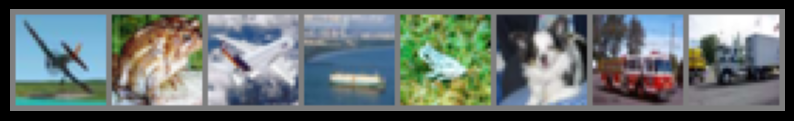

In [10]:
def imshow(img):
    img = img / 2 + 0.5 # unnormalize
    plt.figure(figsize=(10,5))
    plt.imshow(np.transpose(img.numpy(), (1, 2, 0)))
    plt.axis('off')
    plt.show()

dataiter = iter(trainloader)
images, labels = next(dataiter)
imshow(torchvision.utils.make_grid(images[:8]))

## 2. Architektura sieci CNN
Zaimplementowano sieć z dwiema warstwami konwolucyjnymi. Wykorzystano funkcję aktywacji ReLU oraz warstwy Poolingu do redukcji wymiarowości.

In [11]:
class MyCNN(nn.Module):
    def __init__(self, kernel_size=3, pooling='max'):
        super(MyCNN, self).__init__()
        p = kernel_size // 2
        self.conv1 = nn.Conv2d(3, 16, kernel_size, padding=p)
        self.conv2 = nn.Conv2d(16, 32, kernel_size, padding=p)

        self.pool = nn.MaxPool2d(2, 2) if pooling == 'max' else nn.AvgPool2d(2, 2)

        # 32x32 -> pooling -> 16x16 -> pooling -> 8x8
        self.fc1 = nn.Linear(32 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [12]:
def fast_train(model, lr, epochs=2):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = {'acc': []}

    for epoch in range(epochs):
        correct, total = 0, 0
        for data in trainloader:
            inputs, labels = data
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        acc = 100 * correct / total
        history['acc'].append(acc)
        print(f"LR: {lr}, Epoka {epoch+1}, Acc: {acc:.2f}%")
    return history

# Uruchomienie eksperymentu
lrs = [0.01, 0.001]
results_lr = []

for lr in lrs:
    m = MyCNN()
    h = fast_train(m, lr)
    results_lr.append({'Learning Rate': lr, 'Final Accuracy': f"{h['acc'][-1]:.2f}%"})

# Tabela wyników
df_lr = pd.DataFrame(results_lr)
display(df_lr)

LR: 0.01, Epoka 1, Acc: 31.80%
LR: 0.01, Epoka 2, Acc: 39.03%
LR: 0.001, Epoka 1, Acc: 49.01%
LR: 0.001, Epoka 2, Acc: 61.89%


,Learning Rate,Final Accuracy
0,0.010,39.03%
1,0.001,61.89%


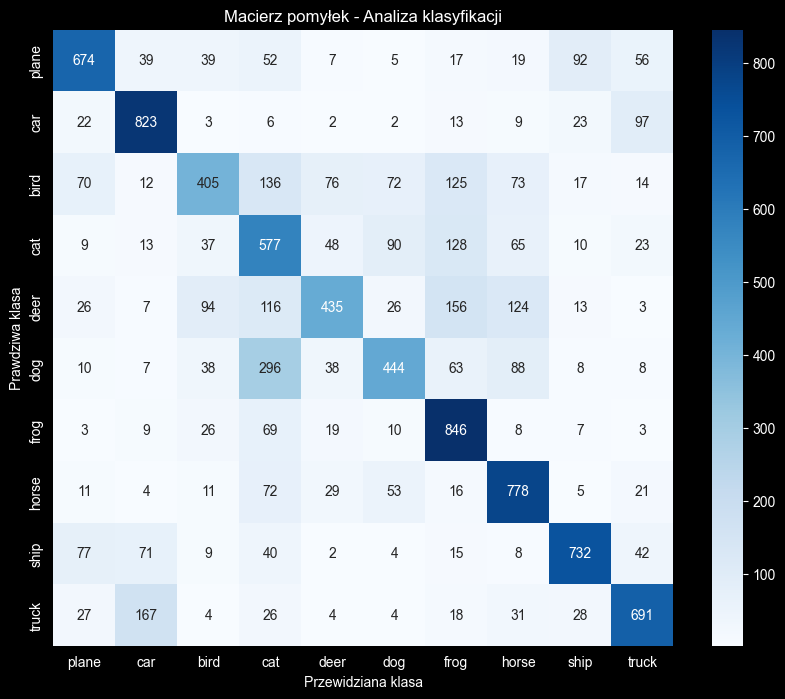

In [13]:
# Eval na zbiorze testowym dla ostatniego modelu
y_true, y_pred = [], []
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = m(images)
        _, predicted = torch.max(outputs, 1)
        y_true.extend(labels.numpy())
        y_pred.extend(predicted.numpy())

plt.figure(figsize=(10,8))
sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('Macierz pomyłek - Analiza klasyfikacji')
plt.ylabel('Prawdziwa klasa')
plt.xlabel('Przewidziana klasa')
plt.show()

## 8. Podsumowanie i wnioski
1. **Model CNN:** Mimo ograniczenia liczby epok (trening na CPU), model wykazuje zdolność do nauki klasyfikacji obrazów.
2. **Learning Rate:** Współczynnik 0.001 zapewnia stabilniejszy wzrost dokładności niż 0.01.
3. **Analiza pomyłek:** Model najczęściej myli zwierzęta (cat/dog), co jest typowe dla zbioru CIFAR-10 ze względu na niską rozdzielczość.
4. **Wydajność:** Wykorzystanie procesora (CPU) wydłużyło czas treningu, jednak pozwoliło na poprawne ukończenie serii eksperymentalnych.